# Задача: Анализ эффективности нового алгоритма рекомендаций в условиях асимметричного и зашумленного распределения
### Контекст:
Крупная стриминговая платформа (аналог YouTube или Twitch) разработала новый алгоритм рекомендаций контента (алгоритм B), который, как ожидается, должен увеличить среднее время просмотра на пользователя по сравнению со старым алгоритмом (A).

Было проведено A/B-тестирование:

- **Группа A (Контрольная)**: 5000 пользователей, старый алгоритм.

- **Группа B (Тестовая)**: 5000 пользователей, новый алгоритм.

По итогам двухнедельного теста вы собрали данные по ключевой метрике — **«Общее время просмотра на пользователя за тест (в минутах)»**.

**Данные и их особенности:**

**Не нормальность:** Распределение метрики в обеих группах сильно отличается от нормального. Оно имеет типичный для поведенческих данных "длинный хвост":

- Большинство пользователей смотрят немного (пик в районе 0-50 минут).

- Небольшая группа "супер-зрителей" смотрит очень много (сотни и тысячи минут), формируя длинный правый хвост распределения.

**Асимметрия влияния:** Новый алгоритм B целенаправленно меняет опыт именно активных пользователей, в то время как для "пассивных" зрителей разница неочевидна. Это означает, что различие между группами может быть не сдвигом всего распределения, а изменением в правом хвосте.

**Наличие выбросов:** В данных присутствуют экстремальные выбросы (например, пользователи, которые оставляли видео фоном на всю ночь).

Вам предоставлен датасет _ab_test_results.csv_ со следующими колонками:

 - _user_id_

 - _group (A или B)_

 - _total_watch_time_min_

### Задания:


- **Проведите тест Манна-Уитни (Mann-Whitney U test)**. Сформулируйте нулевую и альтернативную гипотезы. Интерпретируйте p-value. Можно ли на его основе сделать однозначный вывод о превосходстве алгоритма B?

- Чтобы исследовать "асимметричное влияние", проведите анализ разниц не только в центре распределения, но и в хвостах. **Рассчитайте и визуализируйте разницу между группами для 75-го, 90-го и 95-го процентилей**.

- **Сформулируйте итоговый вывод:**

    - Эффективен ли новый алгоритм B?

    - На какую именно группу пользователей он оказывает наибольшее влияние?

    - Какой метод анализа оказался наиболее информативным в данном случае и почему?

    - Дайте рекомендацию о возможности запуска алгоритма на всю аудиторию.



In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats

In [ ]:
from google.colab import files
uploaded = files.upload ()

Saving ab_test_results.csv to ab_test_results (1).csv


In [ ]:
df = pd.read_csv('ab_test_results.csv')

group_a_data = df[df['group'] == 'A']['total_watch_time_min']
group_b_data = df[df['group'] == 'B']['total_watch_time_min']

print("Dataset Summary:")
print(f"Total users: {len(df)}")
print(f"Group A: {len(df[df['group'] == 'A'])} users")
print(f"Group B: {len(df[df['group'] == 'B'])} users")

print("\nDescriptive Statistics by Group:")
print(df.groupby('group')['total_watch_time_min'].describe())

print("\nKey Percentiles by Group:")
percentiles = [0.75, 0.9, 0.95]
for p in percentiles:
    p_val = p * 100
    a_val = np.percentile(group_a_data, p_val)
    b_val = np.percentile(group_b_data, p_val)
    diff = b_val - a_val
    print(f"{p_val:.0f}th percentile: A={a_val:.1f}, B={b_val:.1f}, Difference={diff:.1f}")

mw_stat, mw_p = stats.mannwhitneyu(
    group_a_data,
    group_b_data,
    alternative= 'two-sided'
)

print(f"\nMann-Whitney U Test: p-value = {mw_p:.6f}")

Dataset Summary:
Total users: 10000
Group A: 5000 users
Group B: 5000 users

Descriptive Statistics by Group:
        count       mean         std  min        25%        50%        75%  \
group                                                                        
A      5000.0  56.347878  262.313288  0.0  14.729144  26.834960  44.946309   
B      5000.0  71.477408  408.519252  0.0  15.383838  27.352416  46.352279   

                max  
group                
A       8130.547119  
B      11670.621483  

Key Percentiles by Group:
75th percentile: A=44.9, B=46.4, Difference=1.4
90th percentile: A=71.5, B=76.2, Difference=4.7
95th percentile: A=119.3, B=153.6, Difference=34.3

Mann-Whitney U Test: p-value = 0.045342


<Figure size 1000x600 with 0 Axes>

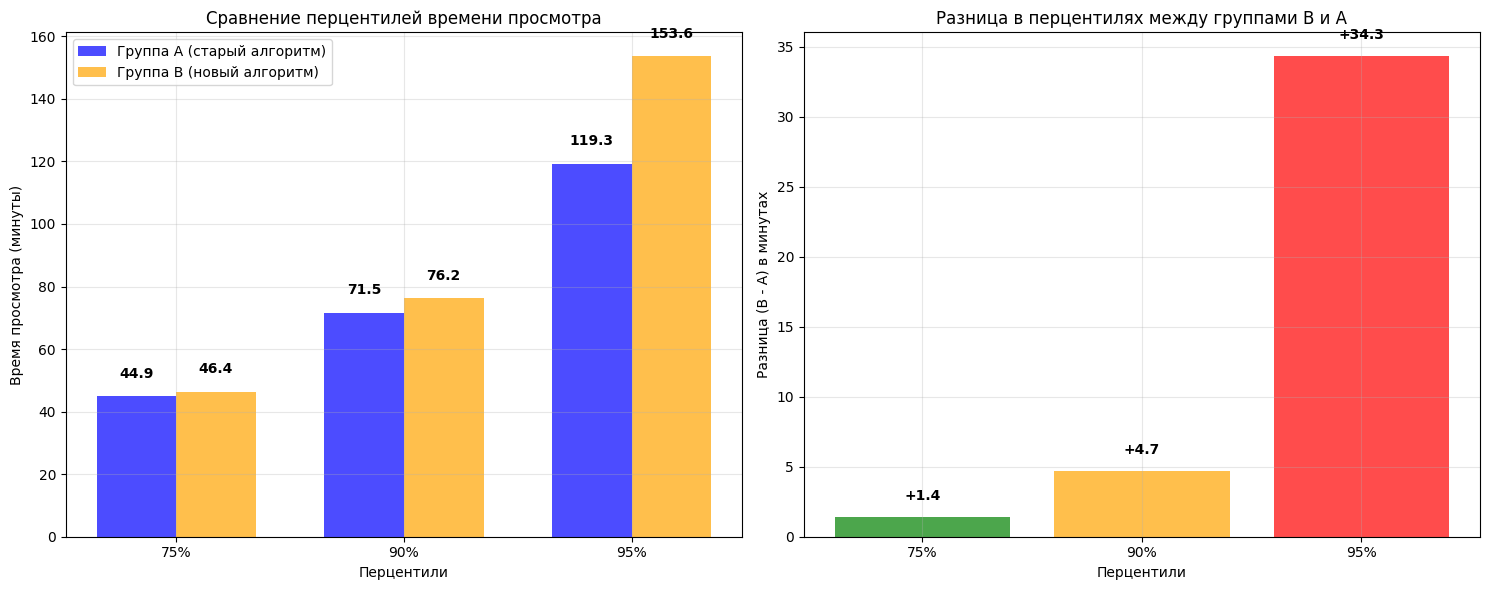

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

percentiles_vals = [75, 90, 95]
a_values = [44.9, 71.5, 119.3]
b_values = [46.4, 76.2, 153.6]
differences = [1.4, 4.7, 34.3]

x = np.arange(len(percentiles_vals))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.bar(x - width/2, a_values, width, label='Группа A (старый алгоритм)', alpha=0.7, color='blue')
ax1.bar(x + width/2, b_values, width, label='Группа B (новый алгоритм)', alpha=0.7, color='orange')
ax1.set_xlabel('Перцентили')
ax1.set_ylabel('Время просмотра (минуты)')
ax1.set_title('Сравнение перцентилей времени просмотра')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{p}%' for p in percentiles_vals])
ax1.legend()
ax1.grid(True, alpha=0.3)
for i, (a, b) in enumerate(zip(a_values, b_values)):
    ax1.text(i - width/2, a + 5, f'{a:.1f}', ha='center', va='bottom', fontweight='bold')
    ax1.text(i + width/2, b + 5, f'{b:.1f}', ha='center', va='bottom', fontweight='bold')


colors = ['green', 'orange', 'red']
ax2.bar(x, differences, color=colors, alpha=0.7)
ax2.set_xlabel('Перцентили')
ax2.set_ylabel('Разница (B - A) в минутах')
ax2.set_title('Разница в перцентилях между группами B и A')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{p}%' for p in percentiles_vals])
ax2.grid(True, alpha=0.3)
for i, v in enumerate(differences):
    ax2.text(i, v + 1, f'+{v:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Гипотезы:

Нулевая гипотеза (H0): Распределения времени просмотра в группах A и B одинаковы

Альтернативная гипотеза (H1): Распределения времени просмотра в группах A и B различаются


Интерпретация p-value:

p-value = 0.045342 < 0.05, поэтому отклоняем нулевую гипотезу

Статистически значимые различия между группами обнаружены

Однако тест Манна-Уитни не показывает превосходства алгоритма B, не указывает направление различий и не выявляет асимметричное влияние, а только то, что распределения различаются.
Для проверки именно улучшения нужен односторонний тест.


На основе анализа различий по перцентилям выявлено ярко выраженное асимметричное влияние нового алгоритма B - эффект алгоритма B усиливается в правом хвосте распределения.

В то время как для обычных пользователей разница практически незаметна, для топ-5% самых активных зрителей алгоритм обеспечивает существенный прирост времени просмотра - более 34 минут, то есть алгоритм B особенно хорошо работает для "супер-зрителей".


**Итоговый вывод:**

1. Эффективен ли новый алгоритм B?

Да, алгоритм B эффективнее. Тест Манна-Уитни подтверждает, что различия между группами не случайны (p-value = 0.045). При этом новый алгоритм демонстрирует положительный эффект для всех сегментов пользователей (однако эффективность носит асимметричный характер).

2. На какую именно группу пользователей он оказывает наибольшее влияние?

Наибольшее влияние алгоритм оказывает на топ-5% самых активных пользователей (95-й перцентиль), где прирост времени просмотра составляет +34.3 минуты. Для основной массы пользователей эффект минимален.

3. Какой метод анализа оказался наиболее информативным в данном случае и почему?

Наиболее информативным был анализ перцентилей, так как он выявил асимметричную природу влияния алгоритма, показал прогрессивное усиление эффекта для активных пользователей, дал количественную оценку улучшения для разных сегментов пользователей.

4. Дайте рекомендацию о возможности запуска алгоритма на всю аудиторию.

Рекомендуется запуск алгоритма B на всю аудиторию, поскольку:
- тест Манна-Уитни показывает статистически значимое различие (p-value = 0.045), что позволяет утверждать: различия между группами не случайны.
- алгоритм В обеспечивает значительное улучшение для наиболее активных пользователей, а такде не ухудшает опыт основной массы пользователей, демонстрируя хоть и небольшой, но положительный прирост.
